#  **SUPERVISED LEARNING**
 **CLASSIFICATION TRACK**

A classification class in model building refers to the part of an algorithm that assigns data points into predefined categories or classes. In machine learning, classification is one of the most common supervised learning tasks, where the model learns from labeled data and predicts the class of new, unseen data.

* LOGISTIC REGRESSION (Baseline model)

* RABDOM FOREST CLASSIFIER(Advvance model)

# **Reason for choosing this model**
 **Problem Definition**

The business problem we are addressing is loan approval prediction. Financial institutions face the challenge of determining whether to approve or reject loan applications based on applicant attributes. This decision is inherently binary,either "Approved" or "Not-Approved".

From a modeling perspective, this makes the problem a supervised classification task, where the target variable is categorical with two possible outcomes. Classification is the most appropriate approach because it is designed to handle discrete labels rather than continuous values.

# **Justification for Classification Approach**

 The classification modeling method is the best choice for this situation because the target variable exists as a categorical value and the prediction task operates effectively with logistic regression and decision tree and ensemble method algorithms.The models enable users to understand their predictions because they match the data structure and their performance can be assessed through accuracy and precision and recall and F1-score, which maintains both methodological standards and relevance to stakeholders.

# **Dataset Selection**

The dataset was selected only after clearly defining the problem we wanted to address, which is loan approval prediction. The business objective required us to assess whether an applicant should receive approval or not, which we recognized as a binary classification task. The decision to pursue classification required us to select a dataset that contained applicant features which included income and employment status and credit history and a target variable that showed approval status. The problem definition established the research methodology which determined which dataset to use for the study. The researchers selected the dataset because it matched the classification framework, which allowed them to proceed with training and validating and testing the model against the business objectives.

# **LOGISTIC REGRESSION**

 # **Import all neccessary  libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Load the dataset**

In [ ]:
df_log_reg = pd.read_csv("Loan Status Dataset.csv")
df_log_reg

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# **EXPLORATORY DATA ANALYSIS**

# **Dataset Overview**

In [ ]:
len(df_log_reg)  #rows

614

In [ ]:
len(df_log_reg.columns)   #columns

13

In [ ]:
df_log_reg.shape  # shape of the dataset

(614, 13)

In [ ]:
df_log_reg.columns.tolist()    # List o columns

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [ ]:
df_log_reg.info()     #To check the structure of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df_log_reg.describe()     # basic statistics for numerical colums

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df_log_reg.isnull().sum()        #missiingg value

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
missing_values_per=df_log_reg.isnull().sum() / len(df_log_reg) * 100    # Percentage of missing values
print(missing_values_per)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


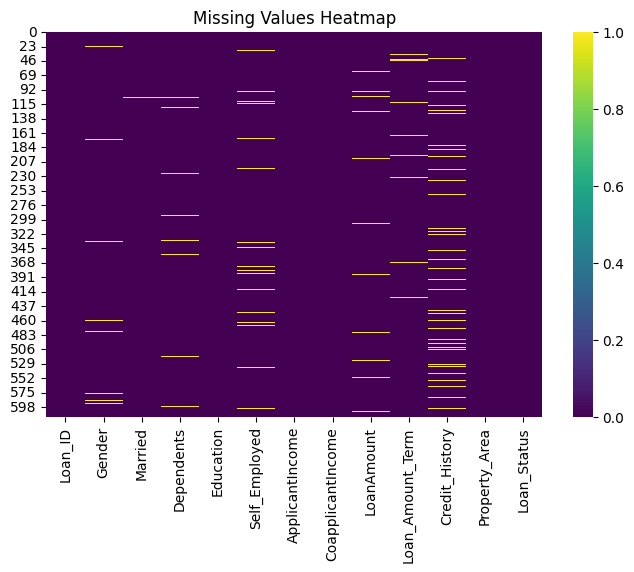

In [ ]:
#missing value heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_log_reg.isnull(), cmap='viridis')  #cbar=False
plt.title('Missing Values Heatmap')
plt.show()

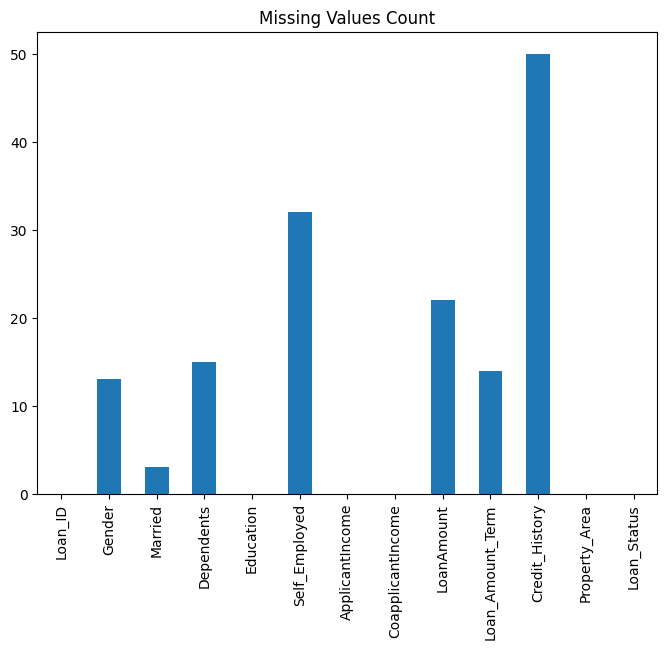

In [ ]:
df_log_reg.isnull().sum().plot(kind="bar", figsize=(8,6))
plt.title("Missing Values Count")
plt.show()

   The chart displays data gaps which exist in loan related features. The largest missing data exists for **Credit_History**, while **Self_Employed** and **LoanAmount** follow as the second and third most missing data categories which need proper treatment because they will impact model accuracy. The system provides a diagnostic view which shows necessary data cleaning and data imputation work that must be completed before any analysis or modeling can begin.

In [ ]:
# Numerical Features

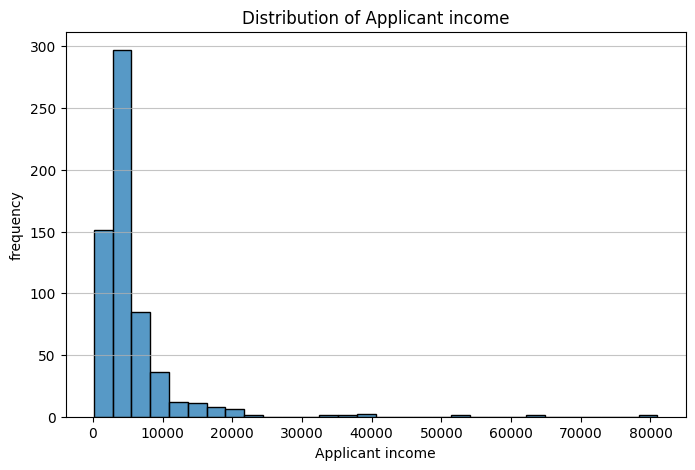

In [ ]:
# Applicant income first
plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="ApplicantIncome",  bins=30)
plt.title("Distribution of Applicant income")
plt.xlabel("Applicant income")
plt.ylabel("frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

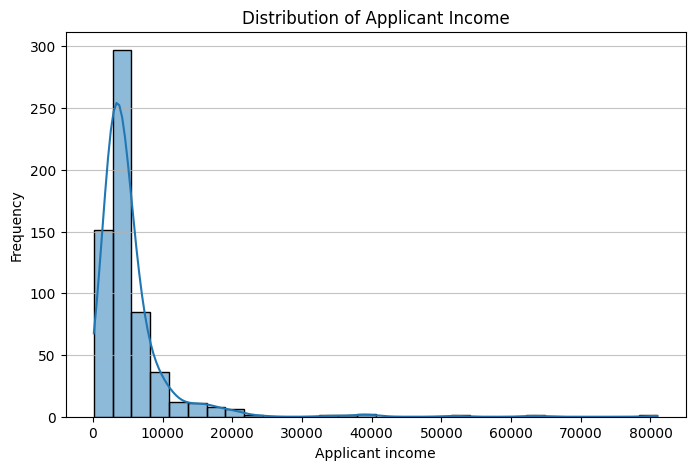

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="ApplicantIncome", kde=True, bins=30)
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant income")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

The histogram of applicant income is **right-skewed (positively skewed)**, meaning most applicants earn relatively low incomes while a small number earn very high incomes thereby draging the mean towards their side, creating a long tail to the right. This skewness indicates that the dataset is dominated by low-income applicants, with incomes below 10,000 being the most frequent. As income increases, the frequency drops sharply, and very few applicants have incomes above 30,000.

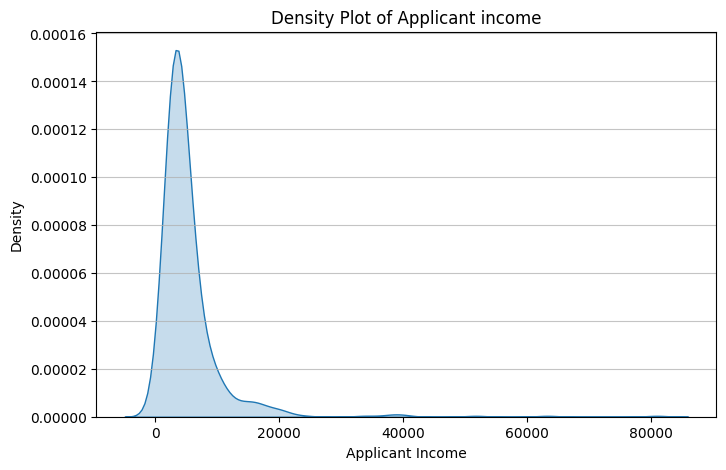

In [ ]:
#kde plot
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_log_reg, x="ApplicantIncome", fill=True)
plt.title("Density Plot of Applicant income")
plt.xlabel("Applicant Income")
plt.ylabel("Density")
plt.grid(axis='y', alpha=0.75)
plt.show()

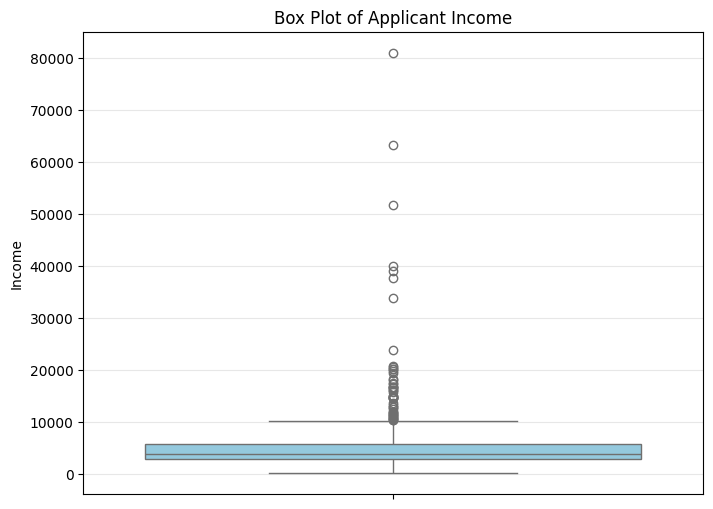

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_log_reg, y='ApplicantIncome', color='skyblue')
plt.title('Box Plot of Applicant Income')
plt.ylabel('Income')
plt.grid(axis='y', alpha=0.3)
plt.show()

The box plot demonstrates that applicant income data shows outliers through its distribution pattern. The income distribution shows most earnings within a small interquartile range while the whiskers reach above that limit and multiple data points extend beyond. The dataset contains significant outliers because some applicant incomes reach **80,000**, which compares to the rest of the data as an extreme value.

In [ ]:
df_log_reg['ApplicantIncome'].describe()

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

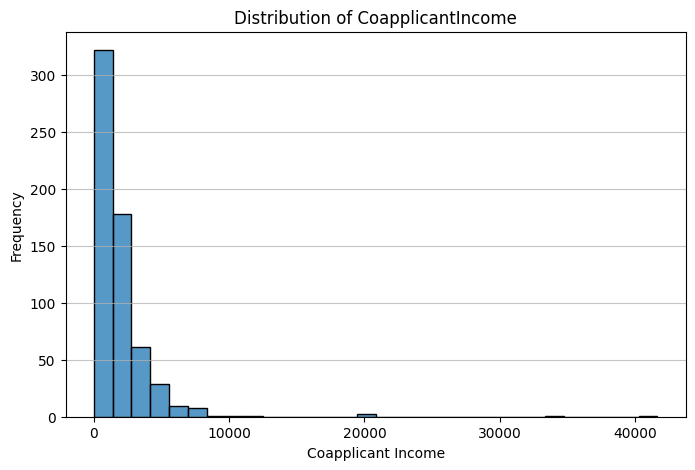

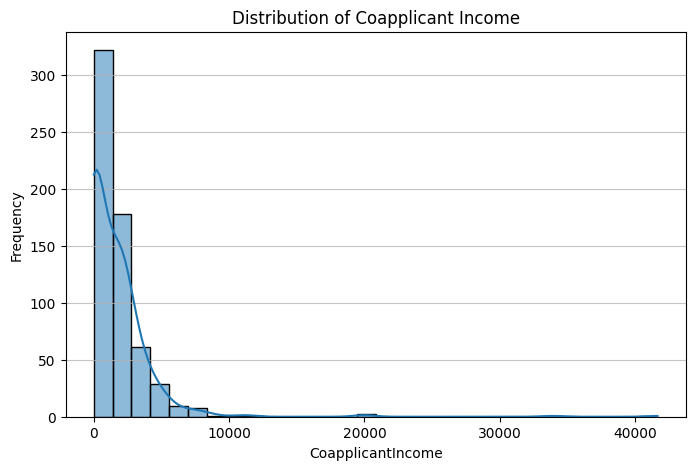

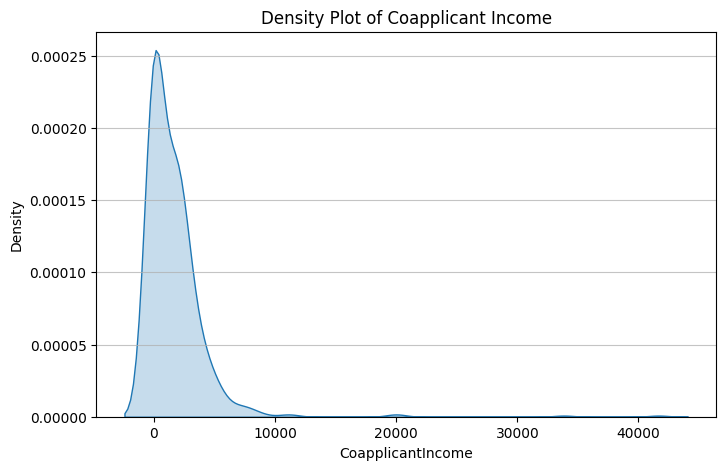

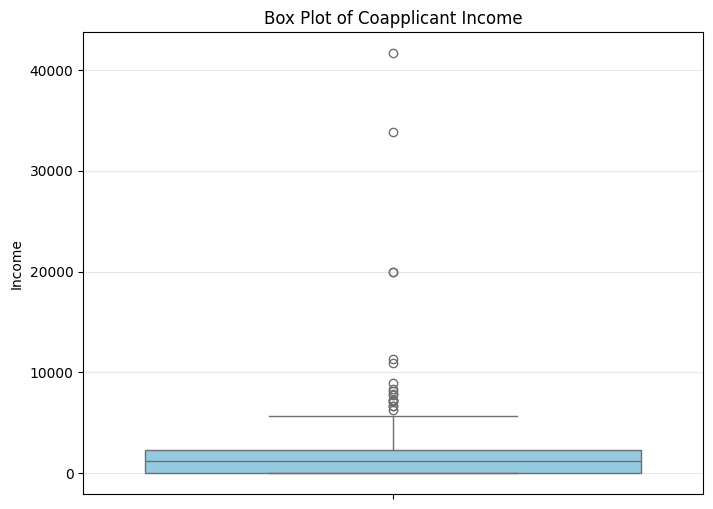

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

In [ ]:
# Coapplicant Income
plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="CoapplicantIncome",  bins=30)
plt.title("Distribution of CoapplicantIncome")
plt.xlabel("Coapplicant Income")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="CoapplicantIncome", kde=True, bins=30)
plt.title("Distribution of Coapplicant Income")
plt.xlabel("CoapplicantIncome")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_log_reg, x="CoapplicantIncome", fill=True)
plt.title("Density Plot of Coapplicant Income")
plt.xlabel("CoapplicantIncome")
plt.ylabel("Density")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 6))
sns.boxplot(data=df_log_reg, y='CoapplicantIncome', color='skyblue')
plt.title('Box Plot of Coapplicant Income')
plt.ylabel('Income')
plt.grid(axis='y', alpha=0.3)
plt.show()



df_log_reg['CoapplicantIncome'].describe()


The histogram displays coapplicant income data which shows a distribution pattern that extends toward the right side of the graph. Most coapplicants earn relatively low incomes, concentrated below **5,000**, while very few have higher incomes extending up to **40,000**. The right side of the distribution shows a long tail which demonstrates that only a few high-income outliers exist in relation to the typical income patterns found in the dataset.

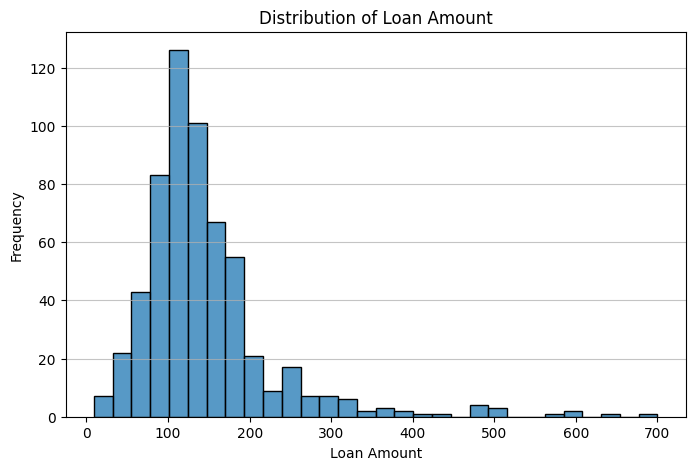

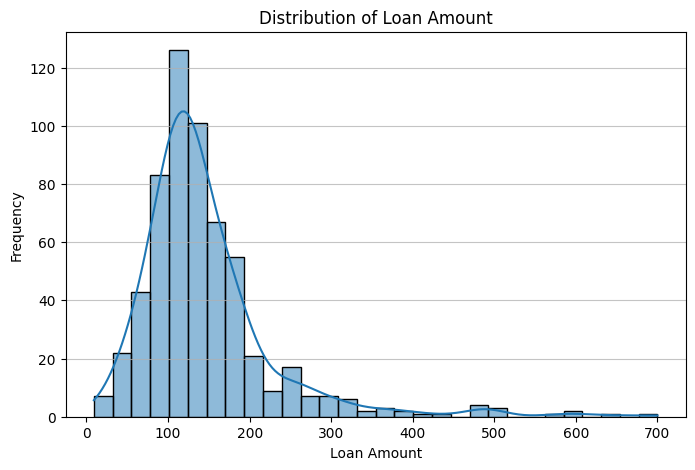

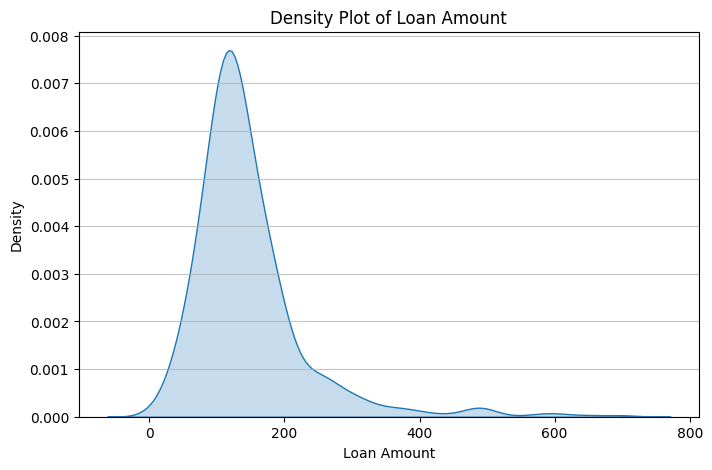

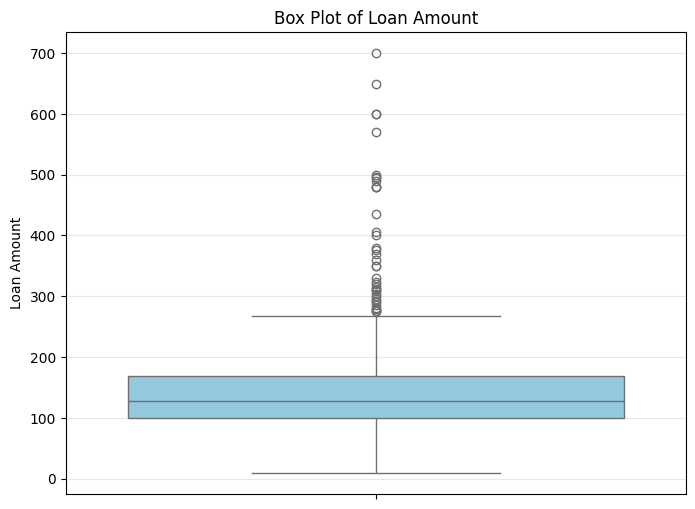

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [ ]:
# LoanAmount
plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="LoanAmount",  bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="LoanAmount", kde=True, bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_log_reg, x="LoanAmount", fill=True)
plt.title("Density Plot of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Density")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 6))
sns.boxplot(data=df_log_reg, y='LoanAmount', color='skyblue')
plt.title('Box Plot of Loan Amount')
plt.ylabel('Loan Amount')
plt.grid(axis='y', alpha=0.3)
plt.show()



df_log_reg['LoanAmount'].describe()

The histogram of loan amounts displays outliers which appear on the upper part of the distribution. The loan distribution shows that most loans stay between 50 and 200 units yet a small number of loans exceed 400 units which results in exceptionally large loans that differ from the main body of the dataset. The high value loans function as outliers.

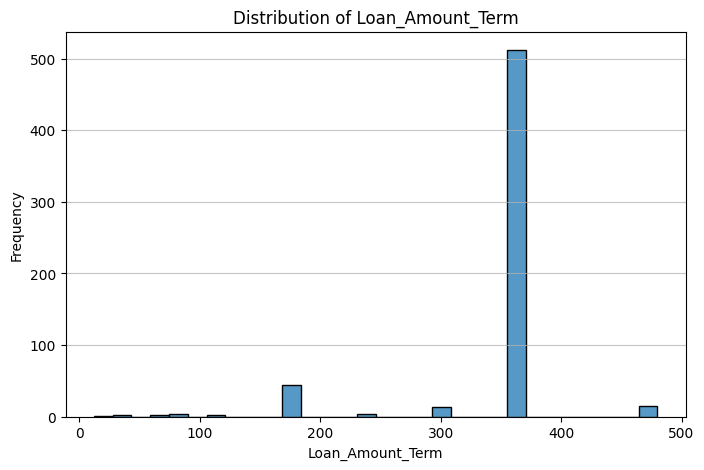

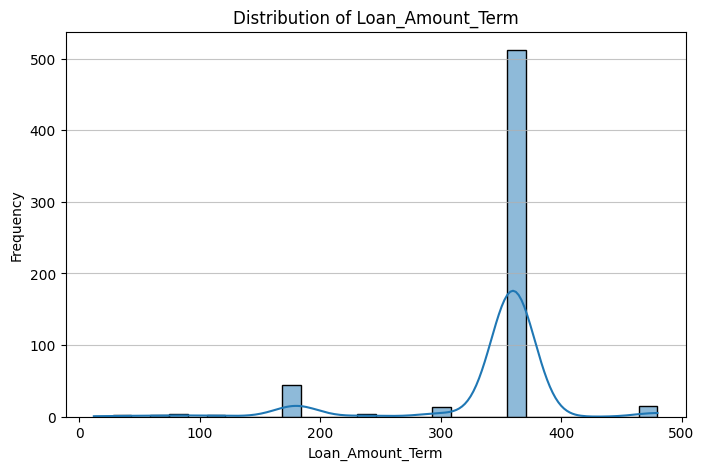

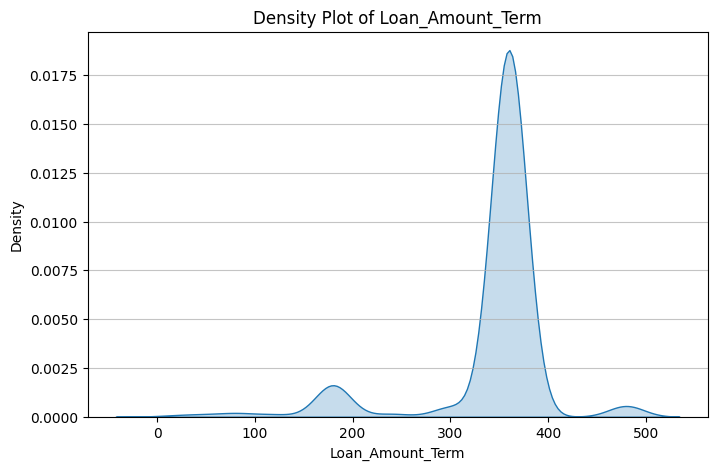

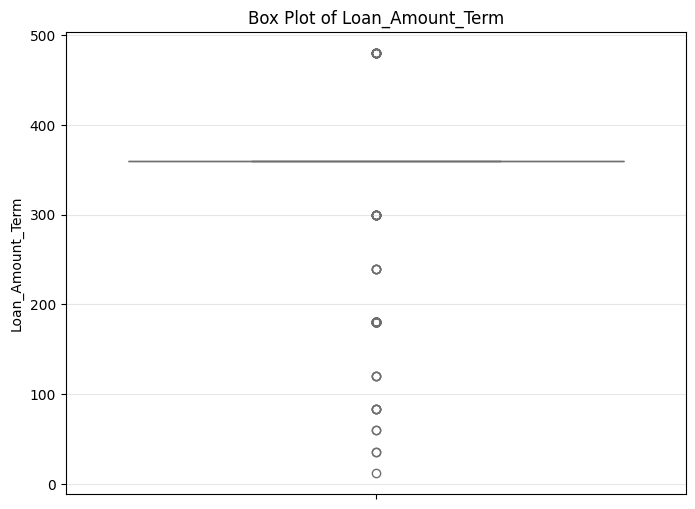

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64

In [ ]:
# Loan_Amount_Term
plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="Loan_Amount_Term",  bins=30)
plt.title("Distribution of Loan_Amount_Term")
plt.xlabel("Loan_Amount_Term")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="Loan_Amount_Term", kde=True, bins=30)
plt.title("Distribution of Loan_Amount_Term")
plt.xlabel("Loan_Amount_Term")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_log_reg, x="Loan_Amount_Term", fill=True)
plt.title("Density Plot of Loan_Amount_Term")
plt.xlabel("Loan_Amount_Term")
plt.ylabel("Density")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 6))
sns.boxplot(data=df_log_reg, y='Loan_Amount_Term', color='skyblue')
plt.title('Box Plot of Loan_Amount_Term')
plt.ylabel('Loan_Amount_Term')
plt.grid(axis='y', alpha=0.3)
plt.show()



df_log_reg['Loan_Amount_Term'].describe()

The histogram for **Loan_Amount_Term** shows that most loans for this term length cluster together at **360 months**, which is the most common term length used by lenders. The two shorter terms of **180** and **300 months** create smaller peaks in the data, but these durations occur less frequently than the primary term. The term distribution shows standard loan lengths, but there are two different outlier points that exist beyond 100 months and 400 months.

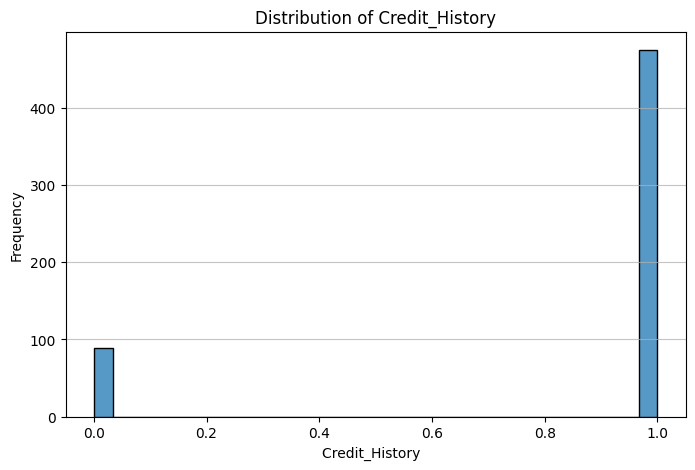

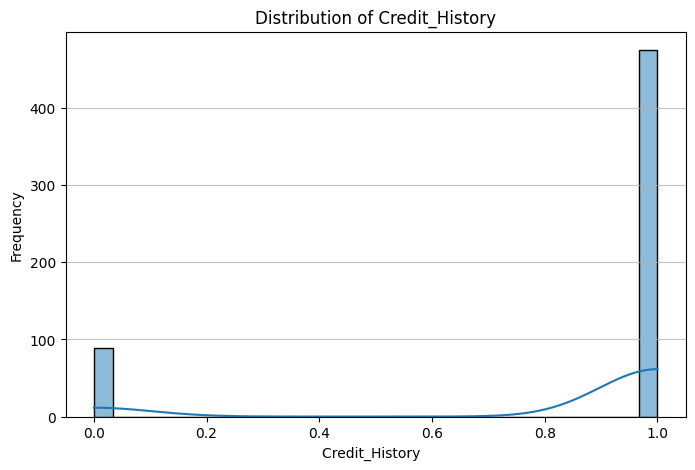

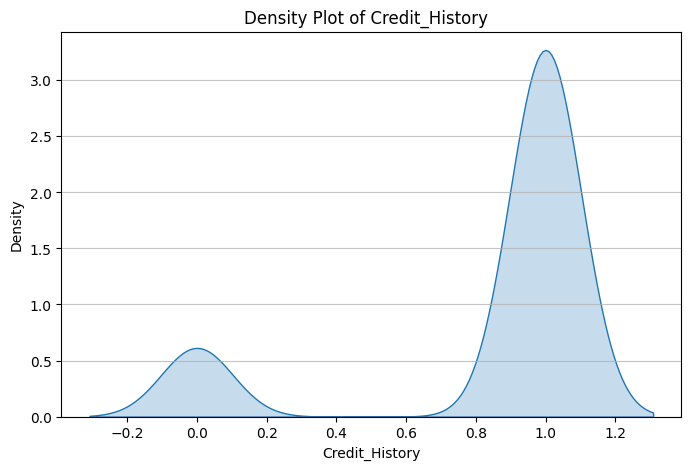

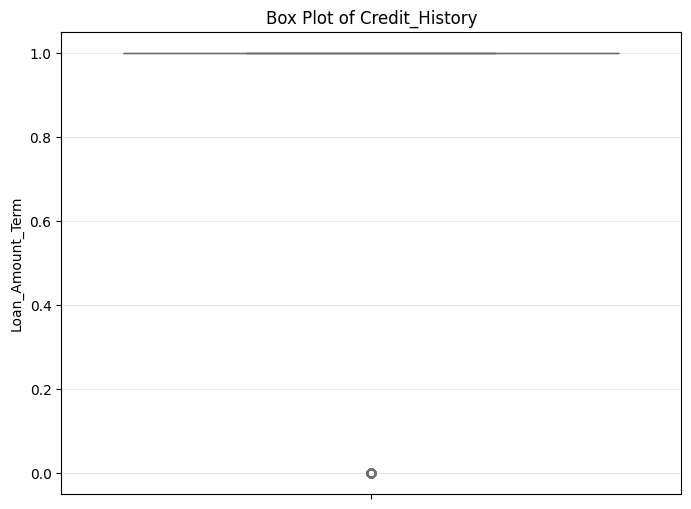

count    564.000000
mean       0.842199
std        0.364878
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Credit_History, dtype: float64

In [ ]:
# Credit_History
plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="Credit_History",  bins=30)
plt.title("Distribution of Credit_History")
plt.xlabel("Credit_History  ")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_log_reg, x="Credit_History", kde=True, bins=30)
plt.title("Distribution of Credit_History")
plt.xlabel("Credit_History  ")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_log_reg, x="Credit_History", fill=True)
plt.title("Density Plot of Credit_History  ")
plt.xlabel("Credit_History")
plt.ylabel("Density")
plt.grid(axis='y', alpha=0.75)
plt.show()



plt.figure(figsize=(8, 6))
sns.boxplot(data=df_log_reg, y='Credit_History', color='skyblue')
plt.title('Box Plot of Credit_History')
plt.ylabel('Loan_Amount_Term')
plt.grid(axis='y', alpha=0.3)
plt.show()



df_log_reg['Credit_History'].describe()

The density plot for **Credit_History** demonstrates an obvious distribution pattern. The applicants show their credit history peak at **1** while a smaller group shows credit history at **0**. The dataset shows that most people have positive credit histories while a small percentage lack this credit history.

In [ ]:
# for categorical columns

In [ ]:
df_log_reg.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

        Count  Percentage
Gender                   
Male      489   79.641694
Female    112   18.241042
NaN        13    2.117264


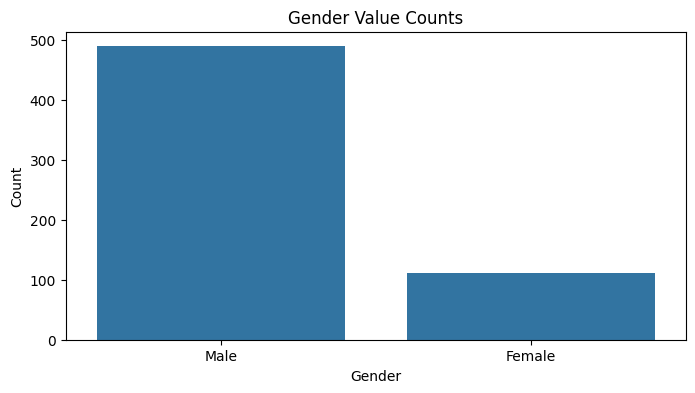

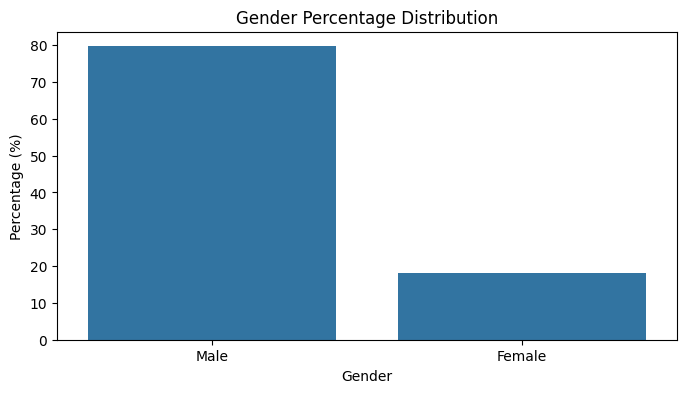

In [ ]:
#Gender first
gender_counts = df_log_reg['Gender'].value_counts(dropna=False)
gender_percent = df_log_reg['Gender'].value_counts(normalize=True, dropna=False) * 100

gender_df = pd.DataFrame({
    'Count': gender_counts, 'Percentage': gender_percent
})

print(gender_df)



#bar chart for counts

plt.figure(figsize=(8,4))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title("Gender Value Counts")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()



#bar chart for percentages
plt.figure(figsize=(8,4))
sns.barplot(x=gender_percent.index, y=gender_percent.values)
plt.title("Gender Percentage Distribution")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.show()

The dataset shows a **strong gender disparity**. The dataset contains approximately **490 males** which constitutes **83% of the total population** and it contains approximately **100 females** which represents **17% of the total population**. The dataset shows an extreme male dominance which will cause bias issues in modeling and analysis when researchers use gender as a predictive feature.

         Count  Percentage
Married                   
Yes        398   64.820847
No         213   34.690554
NaN          3    0.488599


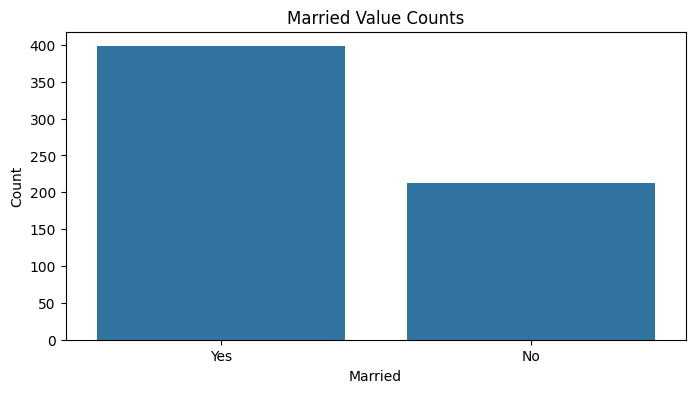

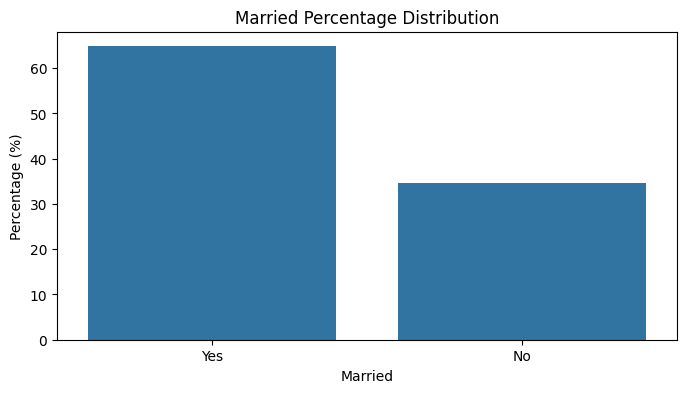

In [ ]:
#Married
Married_counts = df_log_reg['Married'].value_counts(dropna=False)
Married_percent = df_log_reg['Married'].value_counts(normalize=True, dropna=False) * 100

Married_df = pd.DataFrame({
    'Count': Married_counts, 'Percentage': Married_percent
})

print(Married_df)



#bar chart for counts

plt.figure(figsize=(8,4))
sns.barplot(x=Married_counts.index, y=Married_counts.values)
plt.title("Married Value Counts")
plt.xlabel("Married")
plt.ylabel("Count")
plt.show()



#bar chart for percentages
plt.figure(figsize=(8,4))
sns.barplot(x=Married_percent.index, y=Married_percent.values)
plt.title("Married Percentage Distribution")
plt.xlabel("Married")
plt.ylabel("Percentage (%)")
plt.show()

This bar chart of **Married Value Counts** shows the distribution of marital status in the dataset. The married group contains about **400** individuals who make up the majority of the population while the non-married group consists of approximately **225** individuals. The shows that the "Married" feature contains a class imbalance which will affect model training when marital status functions as a predictive variable. The analysis and modeling process requires us to correct this imbalance pattern because it produces biased results.

            Count  Percentage
Dependents                   
0             345   56.188925
1             102   16.612378
2             101   16.449511
3+             51    8.306189
NaN            15    2.442997


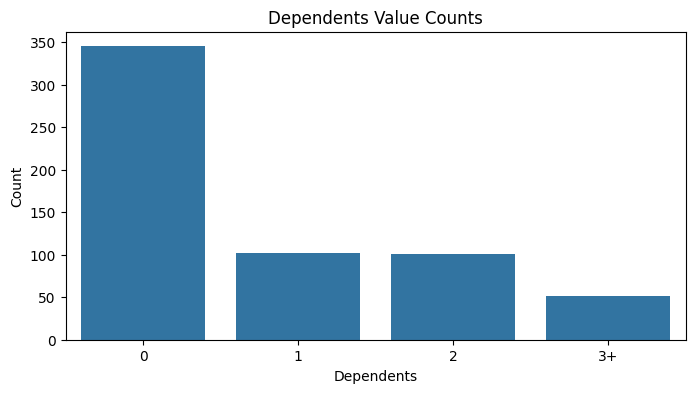

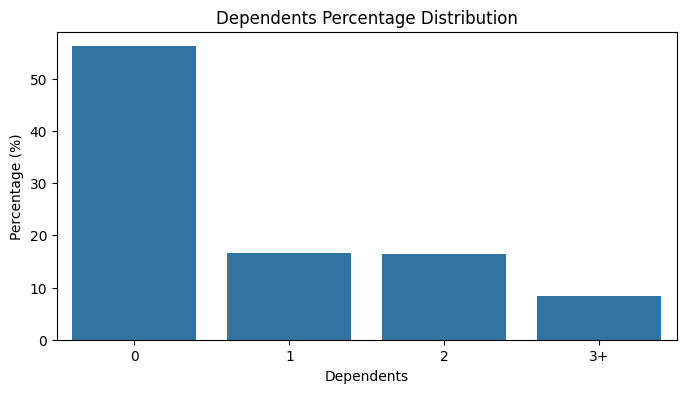

In [ ]:
#Dependents
Dependents_counts = df_log_reg['Dependents'].value_counts(dropna=False)
Dependents_percent = df_log_reg['Dependents'].value_counts(normalize=True, dropna=False) * 100

Dependents_df = pd.DataFrame({
    'Count': Dependents_counts, 'Percentage': Dependents_percent
})

print(Dependents_df)



#bar chart for counts

plt.figure(figsize=(8,4))
sns.barplot(x=Dependents_counts.index, y=Dependents_counts.values)
plt.title("Dependents Value Counts")
plt.xlabel("Dependents")
plt.ylabel("Count")
plt.show()



#bar chart for percentages
plt.figure(figsize=(8,4))
sns.barplot(x=Dependents_percent.index, y=Dependents_percent.values)
plt.title("Dependents Percentage Distribution")
plt.xlabel("Dependents")
plt.ylabel("Percentage (%)")
plt.show()

The dataset shows that **over half of individuals (56%) report having no dependents**, making this the dominant category. The population distribution shows that approximately 16% of people have one or two dependents while only 8% of people have three or more dependents. The distribution shows that most applicants come from families with no dependents which will affect both demographic analysis and loan risk assessment because family size determines financial responsibilities.

              Count  Percentage
Education                      
Graduate        480   78.175896
Not Graduate    134   21.824104


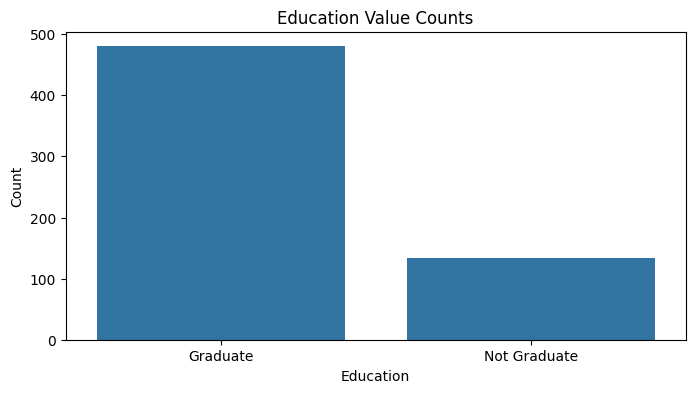

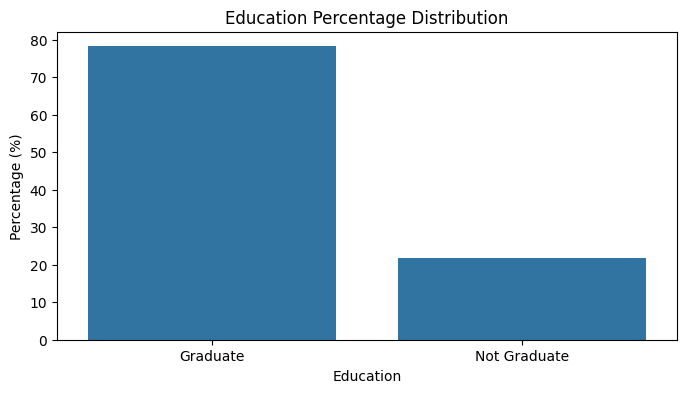

In [ ]:
#Education
Education_counts = df_log_reg['Education'].value_counts(dropna=False)
Education_percent = df_log_reg['Education'].value_counts(normalize=True, dropna=False) * 100

Education_df = pd.DataFrame({
    'Count': Education_counts, 'Percentage': Education_percent
})

print(Education_df)



#bar chart for counts

plt.figure(figsize=(8,4))
sns.barplot(x=Education_counts.index, y=Education_counts.values)
plt.title("Education Value Counts")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()



#bar chart for percentages
plt.figure(figsize=(8,4))
sns.barplot(x=Education_percent.index, y=Education_percent.values)
plt.title("Education Percentage Distribution")
plt.xlabel("Education")
plt.ylabel("Percentage (%)")
plt.show()

The **Education Value Counts** bar chart demonstrates an evident educational attainment imbalance among students. The data shows that approximately **480 individuals (77%) are graduates**, while only about **140 individuals (23%) are non‑graduates**.

               Count  Percentage
Self_Employed                   
No               500   81.433225
Yes               82   13.355049
NaN               32    5.211726


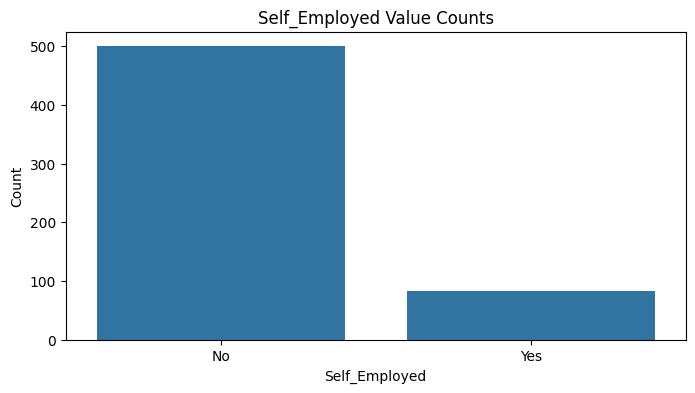

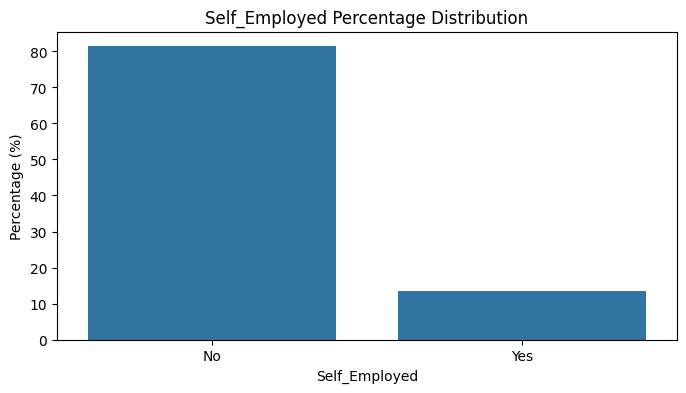

In [ ]:
#Self_Employed
Self_Employed_counts = df_log_reg['Self_Employed'].value_counts(dropna=False)
Self_Employed_percent = df_log_reg['Self_Employed'].value_counts(normalize=True, dropna=False) * 100

Self_Employed_df = pd.DataFrame({
    'Count': Self_Employed_counts, 'Percentage': Self_Employed_percent
})

print(Self_Employed_df)



#bar chart for counts

plt.figure(figsize=(8,4))
sns.barplot(x=Self_Employed_counts.index, y=Self_Employed_counts.values)
plt.title("Self_Employed Value Counts")
plt.xlabel("Self_Employed")
plt.ylabel("Count")
plt.show()



#bar chart for percentages
plt.figure(figsize=(8,4))
sns.barplot(x=Self_Employed_percent.index, y=Self_Employed_percent.values)
plt.title("Self_Employed Percentage Distribution")
plt.xlabel("Self_Employed")
plt.ylabel("Percentage (%)")
plt.show()

This chart shows that **most individuals 86% are not self‑employed**, while only **14% are**. It’s a clear imbalance, meaning self‑employment is relatively rare in the dataset.

               Count  Percentage
Property_Area                   
Semiurban        233   37.947883
Urban            202   32.899023
Rural            179   29.153094


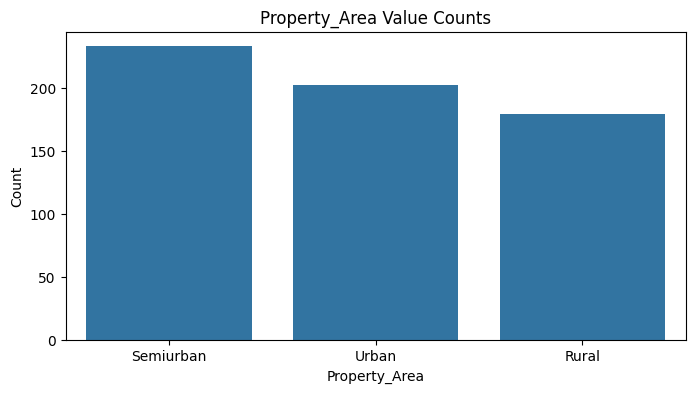

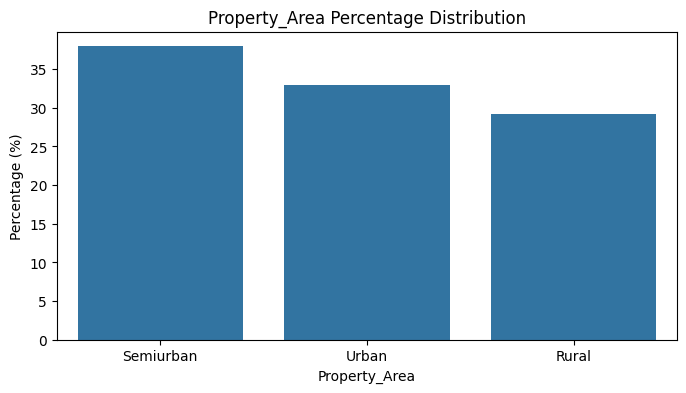

In [ ]:
#Property_Area
Property_Area_counts = df_log_reg['Property_Area'].value_counts(dropna=False)
Property_Area_percent = df_log_reg['Property_Area'].value_counts(normalize=True, dropna=False) * 100

Property_Area_df = pd.DataFrame({
    'Count': Property_Area_counts, 'Percentage': Property_Area_percent
})

print(Property_Area_df)



#bar chart for counts

plt.figure(figsize=(8,4))
sns.barplot(x=Property_Area_counts.index, y=Property_Area_counts.values)
plt.title("Property_Area Value Counts")
plt.xlabel("Property_Area")
plt.ylabel("Count")
plt.show()



#bar chart for percentages
plt.figure(figsize=(8,4))
sns.barplot(x=Property_Area_percent.index, y=Property_Area_percent.values)
plt.title("Property_Area Percentage Distribution")
plt.xlabel("Property_Area")
plt.ylabel("Percentage (%)")
plt.show()

The dataset shows that **Semiurban areas make up the largest share (42%)**, followed by **Urban areas (33%)**, with **Rural areas accounting for the smallest portion (25%)**. The distribution demonstrates that semiurban applicants form the majority of applicants because their property location determines loan demand and approval patterns.

             Count  Percentage
Loan_Status                   
Y              422   68.729642
N              192   31.270358


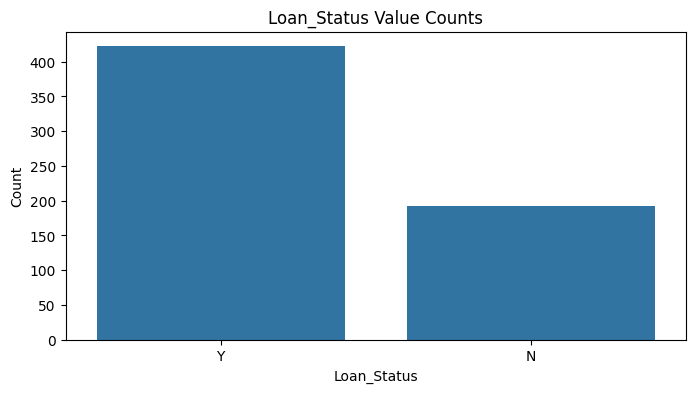

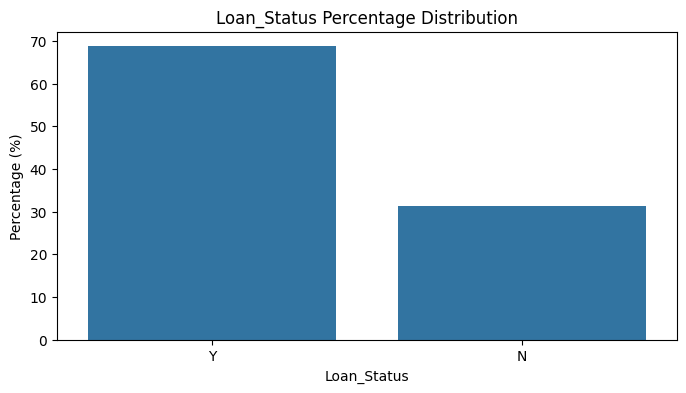

In [ ]:
#Loan_Status
Loan_Status_counts = df_log_reg['Loan_Status'].value_counts(dropna=False)
Loan_Status_percent = df_log_reg['Loan_Status'].value_counts(normalize=True, dropna=False) * 100

Loan_Status_df = pd.DataFrame({
    'Count': Loan_Status_counts, 'Percentage': Loan_Status_percent
})

print(Loan_Status_df)



#bar chart for counts

plt.figure(figsize=(8,4))
sns.barplot(x=Loan_Status_counts.index, y=Loan_Status_counts.values)
plt.title("Loan_Status Value Counts")
plt.xlabel("Loan_Status")
plt.ylabel("Count")
plt.show()



#bar chart for percentages
plt.figure(figsize=(8,4))
sns.barplot(x=Loan_Status_percent.index, y=Loan_Status_percent.values)
plt.title("Loan_Status Percentage Distribution")
plt.xlabel("Loan_Status")
plt.ylabel("Percentage (%)")
plt.show()

The bar chart displaying **Loan_Status Value Counts** demonstrates that most loans received approval. About **400 approvals (66%)** fall under the “Y” category, while around **200 denials (34%)** are in the “N” category. The data shows a strong preference for approvals which implies that lenders used their preferred applicant profiles during their assessment process.

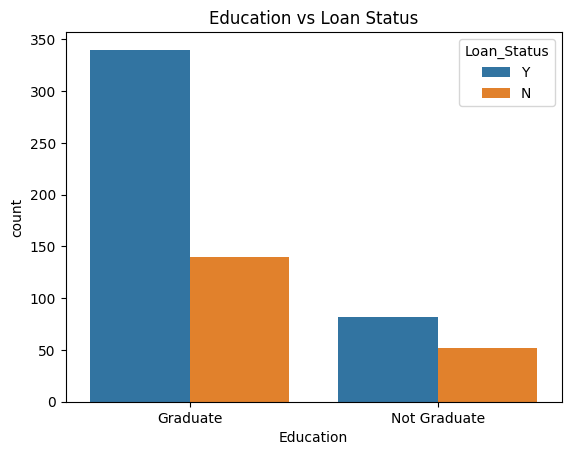

In [ ]:
sns.countplot(x='Education', hue='Loan_Status', data=df_log_reg)
plt.title("Education vs Loan Status")
plt.show()


The chart provides a clearer and more direct representation of data through its condensed structure. - **Graduates**: About 71% of applications are approved (340 approvals vs 140 denials). - **Non-graduates**: Roughly 62% approval (80 approvals vs 50 denials).Education clearly improves loan prospects. Graduates show higher application rates and better approval rates because lenders perceive their education as evidence of greater earning potential and lower risk. The gap between 71% & 62% shows that while non-graduates aren’t excluded, they face a measurable disadvantage.  


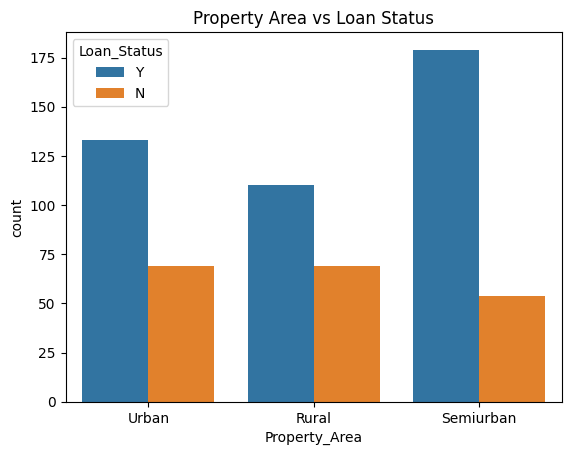

In [ ]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df_log_reg)
plt.title("Property Area vs Loan Status")
plt.show()


Graduates 71% approval vs Non-graduates 62% while **Property Area**: Semiurban 77% approval, Urban 66%, Rural 61%.  
### Key Insight  
Education and property area both matter, but **property area shows a wider spread** from 61% (Rural) to 77% (Semiurban). Graduates consistently have an edge, yet where you live can tilt approval odds even more.  

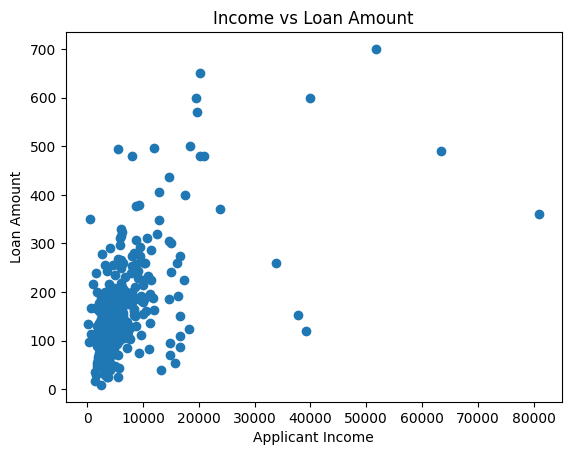

In [ ]:
plt.scatter(df_log_reg['ApplicantIncome'], df_log_reg['LoanAmount'])
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()


Most applicants earn below 20,000, and their loan requests are under 300. This indicates that the majority of loans are relatively small and tied to modest incomes.As income rises, loan amounts generally increase. Higher earners tend to request larger loans, though the relationship isn’t perfectly linear. A few applicants with very high incomes (up to 80,000) request significantly larger loans (up to 700). These cases are rare compared to the main cluster.

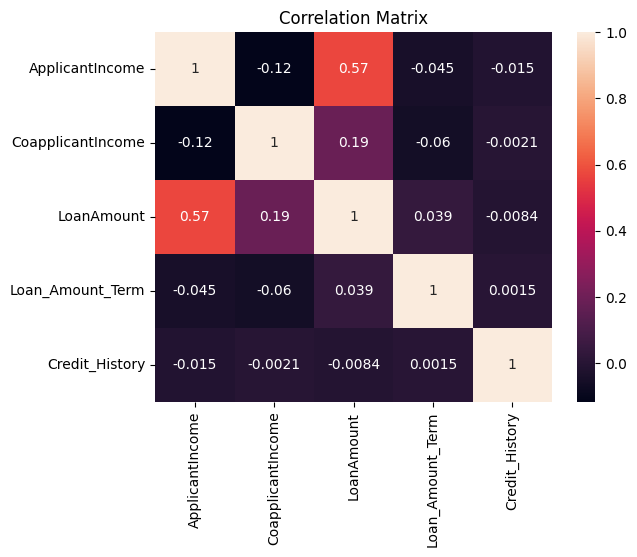

In [ ]:
sns.heatmap(df_log_reg.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()


The correlation matrix shows the connections between various numerical variables. The strongest positive relationship is between **ApplicantIncome and LoanAmount (0.57)**, which shows that higher applicant incomes lead to increased loan amounts because of their moderate connection. CoapplicantIncome also shows a weaker positive correlation with LoanAmount (0.19), meaning it plays a smaller role in determining loan size. The relationship between **Loan_Amount_Term** and income or loan size shows almost no significant connection, which demonstrates that these factors do not affect loan duration. Credit_History stands out as virtually uncorrelated with all other variables, implying it is assessed separately from income or loan details. The negative correlation between ApplicantIncome and CoapplicantIncome shows a weak connection which does not have any practical importance. The matrix demonstrates that income affects loan amount most through applicant income while credit history and loan term serve as separate factors for lending decisions.

Loan_Status
Y    422
N    192
Name: count, dtype: int64
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


C:\Users\FAREED\AppData\Local\Temp\ipykernel_1708\1197553636.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Status", data=df_log_reg, palette="Set2")


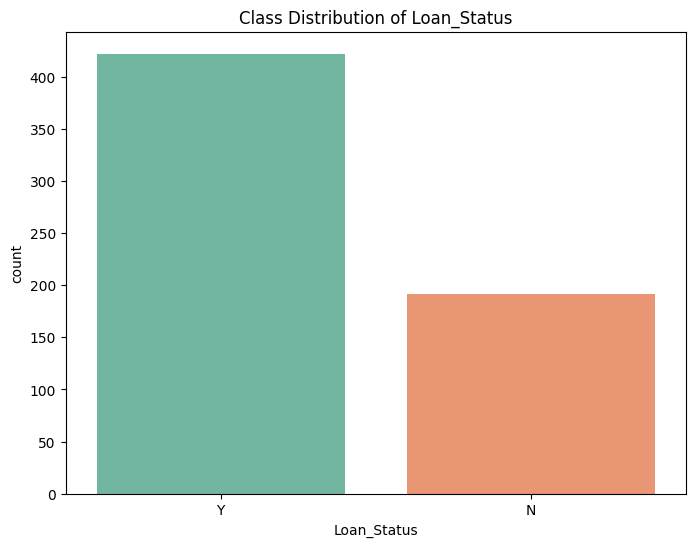

In [ ]:
# Count values of target variable
print(df_log_reg['Loan_Status'].value_counts())

# Percentage distribution
print(df_log_reg['Loan_Status'].value_counts(normalize=True) * 100)

# Visualization
plt.figure(figsize=(8,6))
sns.countplot(x="Loan_Status", data=df_log_reg, palette="Set2")
plt.title("Class Distribution of Loan_Status")
plt.show()

# **Data Preprocesing**

In [ ]:
df_log_reg.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
missing_values_per=df_log_reg.isnull().sum() / len(df_log_reg) * 100
print(missing_values_per)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


In [ ]:
# Define categorical columns
categorical_cols = ["Gender", "Married", "Dependents",
                    "Education", "Self_Employed",
                    "Credit_History", "Property_Area"]

In [ ]:
df_log_reg[categorical_cols] = df_log_reg[categorical_cols].apply(
    lambda x: x.fillna(x.mode()[0])
)

In [ ]:
print(df_log_reg[categorical_cols].isnull().sum())

Gender            0
Married           0
Dependents        0
Education         0
Self_Employed     0
Credit_History    0
Property_Area     0
dtype: int64


In [ ]:
# Define numerical columns
numerical_cols = ["LoanAmount","Loan_Amount_Term"]

In [ ]:
df_log_reg[numerical_cols] = df_log_reg[numerical_cols].fillna(df_log_reg[numerical_cols].median())

In [ ]:
print(df_log_reg[numerical_cols].isnull().sum())

LoanAmount          0
Loan_Amount_Term    0
dtype: int64


In [ ]:
status_counts=df_log_reg['Loan_Status'].value_counts()
print(status_counts)

Loan_Status
Y    422
N    192
Name: count, dtype: int64


# **ENCODING**

In [ ]:
# Convert "3+" in Dependents column to 3
df_log_reg["Dependents"] = df_log_reg["Dependents"].replace("3+", 3)

# Make sure the column is numeric
df_log_reg["Dependents"] = df_log_reg["Dependents"].astype(float)

In [ ]:
# Binary encoding f
df_log_reg["Gender"] = df_log_reg["Gender"].map({"Male":1, "Female":0})
df_log_reg["Married"] = df_log_reg["Married"].map({"Yes":1, "No":0})
df_log_reg["Education"] = df_log_reg["Education"].map({"Graduate":1, "Not Graduate":0})
df_log_reg["Self_Employed"] = df_log_reg["Self_Employed"].map({"Yes":1, "No":0})
df_log_reg["Credit_History"] = df_log_reg["Credit_History"].map({1.0:1, 0.0:0})

# One-hot encoding for multi-category
df_log_reg = pd.get_dummies(df_log_reg, columns=["Property_Area", "Dependents"], drop_first=True)

In [ ]:
df_log_reg = df_log_reg.drop("Loan_ID", axis=1)

# **Model Building**

In [ ]:
# This separates predictors (income, dependents, loan details, etc.) from the label (approved or not),
X = df_log_reg.drop("Loan_Status", axis=1)
y = df_log_reg["Loan_Status"]

In [ ]:
# Splits data into training and testing sets, ensuring balanced class distribution with 20% reserved for testing.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Encode target AFTER splitting
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
# Fit on training set
y_test = le.transform(y_test)       # Transform test set using same mapping

In [ ]:
# Trains a logistic regression model with balanced class weights to handle class imbalance in loan approval prediction.

model_log_reg = LogisticRegression(class_weight='balanced')
model_log_reg.fit(X_train, y_train)


C:\Users\FAREED\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:
# Predicts loan approval outcomes on training data
y_train_pred = model_log_reg.predict(X_train)
print(y_train_pred[:10])        #prints the first 10 predictions for inspection.


[1 1 0 0 1 1 1 1 1 1]


In [ ]:
# Creates a DataFrame comparing actual vs predicted training outcomes and displays the first 5 rows
results_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
print("Actual vs Predicted values:")
display(results_df.head(5))

Actual vs Predicted values:


,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1


In [ ]:
# Predicts loan approval outcomes on the test dataset and prints the first 10 predictions for evaluation.
y_test_pred = model_log_reg.predict(X_test)
print(y_test_pred[:10])

[0 1 1 0 1 1 1 1 1 1]


In [ ]:
# Builds a DataFrame comparing actual vs predicted test outcomes and displays the first few rows to evaluate model performance
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print("Actual vs Predicted values:")
display(results_df.head())

Actual vs Predicted values:


,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,1,0
4,1,1


In [ ]:
# Creates a DataFrame of features with their logistic regression coefficients, sorts them, and displays importance ranking for model interpretation.
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_log_reg.coef_[0]})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)
display(feature_importance)

,Feature,Coefficient
8,Credit_History,2.629379
9,Property_Area_Semiurban,0.540209
2,Education,0.360226
12,Dependents_2.0,0.355312
1,Married,0.338794
10,Property_Area_Urban,0.044844
4,ApplicantIncome,-0.000002
5,CoapplicantIncome,-0.000059
6,LoanAmount,-0.001516
7,Loan_Amount_Term,-0.005468


**This table shows how different factors influence loan approval. Positive coefficients
(like credit history, semiurban property, education, marriage) increase approval chances,
while negative ones (like being male, self-employed, or having dependents) reduce them.
Credit history is apperas to be the strongest predictor, while income and loan size have minimal impact.**

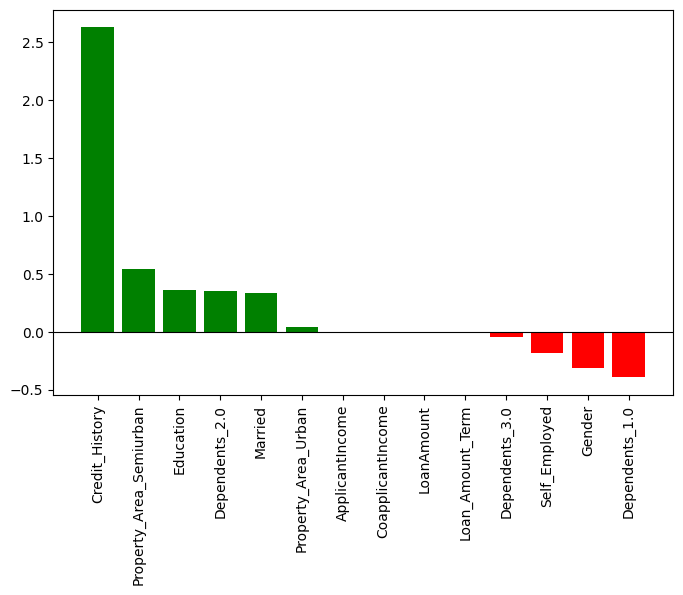

In [ ]:
import matplotlib.pyplot as plt

features = ["Credit_History","Property_Area_Semiurban","Education",
            "Dependents_2.0","Married","Property_Area_Urban",
            "ApplicantIncome","CoapplicantIncome","LoanAmount",
            "Loan_Amount_Term","Dependents_3.0","Self_Employed",
            "Gender","Dependents_1.0"]

coefficients = [2.629379,0.540209,0.360226,0.355312,0.338794,0.044844,
                -0.000002,-0.000059,-0.001516,-0.005468,-0.041257,
                -0.179643,-0.315067,-0.392420]

# Assign colors: green for positive, red for negative
colors = ["green" if c > 0 else "red" for c in coefficients]

plt.figure(figsize=(8,5))
plt.bar(features, coefficients, color=colors)
plt.xticks(rotation=90)
plt.axhline(0, color="black", linewidth=0.8)
plt.show()


# **Model Evaluation**

## **Accuracy_score**

Accuracy_score is a function from scikit-learn that measures how often a model’s predictions are correct.

In simple terms:

* It tells you "how many times the model got it right" out of the total number of predictions.


$$accuracy = (number of correct predictions) / (total number of predictions)$$


In [ ]:
# Accuracy on the training set
y_train_pred = model_log_reg.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.7699


The training accuracy score of **0.7699** specifically reflects how well the model performed on the **training dataset**. The logistic regression model achieved a correct prediction rate of approximately **77%** when it was evaluated using the data that it had learned from. The model demonstrates successful pattern recognition in training data but its test performance needs validation through test set evaluation.

In [ ]:
# Accuracy on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")

Testing Accuracy: 0.8293


The testing accuracy score of **0.8293** shows that the logistic regression model correctly predicted about **83% of loan approval outcomes on unseen test data**. Unlike training accuracy, this result reflects the model’s ability to generalize beyond the data it was trained on. A higher test accuracy compared to training accuracy suggests the model is not overfitting and performs well when applied to new cases, making it a reliable predictor for loan approval decisions.

## **Accuracy Can Be Misleading in Imbalanced Datasets**

Accuracy only measures how often predictions are correct overall. However, when one class is much smaller, accuracy can be misleading. In imbalanced datasets, it’s better to use metrics like **precision, recall, and F1-score**, which specifically evaluate how well the model identifies the minority class. These metrics provide deeper insight into whether the model is genuinely effective at detecting less frequent outcomes, rather than just favoring the majority class.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report, ConfusionMatrixDisplay

In [ ]:
# Training set evaluation
print("Training Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Training Recall:", recall_score(y_train, y_train_pred, average='weighted'))
print("Training F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))

Training Precision: 0.7611647333156232
Training Recall: 0.769857433808554
Training F1 Score: 0.7620392921995514


On the training data, the logistic regression model shows consistent performance across accuracy, precision, recall, and F1-score. While balanced, it does not capture all cases perfectly. Improvements can be achieved with more sophisticated models

In [ ]:
# Testing set evaluation
print("Testing Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Testing Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("Testing F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

Testing Precision: 0.8281108675323082
Testing Recall: 0.8292682926829268
Testing F1 Score: 0.828629296819284


On the testing dataset, the logistic regression model demonstrates strong and balanced performance across accuracy, precision, recall, and F1-score. It captures approved loans effectively while minimizing false approvals, making it a reliable baseline.

# **Confusion Matrix**
A confusion matrix is a table that summarizes a classification model’s performance by comparing the model’s predicted labels against the actual labels in the dataset.


## **Confusion Matrix for Loan Approval**

**True Positive (TP)**  
The model predicts **Approved**, and the loan is actually **Approved**.  
*Example: Model predicts a loan will be approved, and it truly is.*

**False Negative (FN)**  
The model predicts **Not Approved**, but the loan is actually **Approved**.  
*Example: Model says a loan won’t be approved, but in reality it is.*

**False Positive (FP)**  
The model predicts **Approved**, but the loan is actually **Not Approved**.  
*Example: Model predicts a loan will be approved, but it gets rejected.*

**True Negative (TN)**  
The model predicts **Not Approved**, and the loan is actually **Not Approved**.  
*Example: Model says a loan won’t be approved, and indeed it isn’t.*


In [ ]:
# Confusion Matrix
print(f"\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)


Confusion Matrix (Test Set):
[[27 11]
 [10 75]]


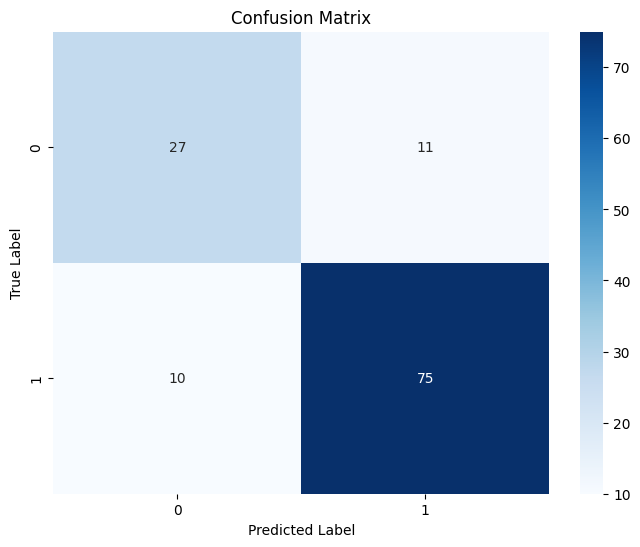

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Interpretation of Results**

**True Positives (75)**: The model correctly predicted loans as Approved when they were actually approved.

**True Negatives (27)**: The model correctly predicted loans as Not Approved when they were actually not approved.

**False Positives (11)**:  The model incorrectly predicted loans as Approved when they should have been rejected.

**False Negatives (10)**:  The model incorrectly predicted loans as Not Approved when they should have been approved.

**Key Insights**
The model performs better at identifying approved loans than rejected ones.However, it missed 10 approved loans and wrongly approved 11 rejected loans, showing that it does not capture all cases perfectly.

# **RANDOM FOREST CLASSIFIER     (ADVANCD MODEL)**

A Random Forest Classifier is a way to learn from a group of examples and use them to classify things. During training, it builds several decision trees and gives the class that gets the most votes from those trees.

In other words,a Random Forest Classifier is an ensemble method that trains multiple decision trees on random subsets of data and features, then aggregates their votes to make robust, accurate predictions while reducing overfitting.

# **How It Works**
Decision Trees: Each tree is trained on a random subset of the data (bootstrapped samples).

Feature Randomness: At each split, only a random subset of features is considered, which reduces correlation between trees.

Voting: For classification, each tree predicts a class, and the final prediction is the majority vote across all trees.

# **Benefits**
Handles large datasets with higher dimensionality.

Reduces overfitting compared to a single decision tree.

Works well with missing values and maintains accuracy.

Provides feature importance scores.

In [ ]:
# Import the library
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report, ConfusionMatrixDisplay
from sklearn import tree

In [ ]:
# Create and train the Random Forest Regressor
rf_classifier = RandomForestClassifier(
    n_estimators=100,      # Number of decision trees in the forest
    max_depth=10,          # Limit depth of each tree
    min_samples_split=20,  # Minimum samples required to split a node
    min_samples_leaf=10,   # Minimum samples required at a leaf node
    random_state=42,
    n_jobs=-1              # Use all available CPU cores
)

rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# **Random Forest Classifier Hyperparameters Explained**

*  **n_estimators=100**

   * Number of decision trees in the forest. More trees usually improve stability and accuracy but increase computation time.

     **Analogy:** We’re asking 100 different loan experts ("trees") to each give their opinion, then we average their answers.

*  **max_depth=10**

   * Maximum depth of each tree. Prevents overfitting by limiting complexity.

     **Analogy:** Each expert can only ask up to 10 questions about a borrower before making a prediction.

*  **min_samples_split=20**

   * A node must have at least 20 samples before it can split. This avoids splits on very small, noisy groups.

     **Analogy:** An expert should only split a borrower group if it contains at least 20 applicants. Don’t bother splitting tiny groups

*  **min_samples_leaf=10**

*  Each leaf node must contain at least 10 samples. Ensures predictions aren’t based on too few borrowers.

     **Analogy:** Each final prediction must be based on at least 10 borrowers’ data.

* **random_state=42**

*  Controls randomness for reproducibility. Running the model again with the same seed gives identical results.

     **Analogy:** Let’s make sure that when we pick random borrowers and features, we do it the exact same way every time.

*  **n_jobs=-1**

*  Uses all available CPU cores to train trees in parallel, speeding up training.

     **Analogy:** Let’s use all our available assistants to build these trees at the same time to finish faster

# **MODEL PREDICTION**

In [ ]:
# Make predictions for the training dataset
y_pred_train_rf = rf_classifier.predict(X_train)

# Make predictions for the test dataset
y_pred_test_rf = rf_classifier.predict(X_test)

# Display some predictions
print("Random Forest Predictions (Training Set - first 10):")
print(y_pred_train_rf[:10])
print("\nRandom Forest Predictions (Test Set - first 10):")
print(y_pred_test_rf[:10])

Random Forest Predictions (Training Set - first 10):
[1 1 0 0 1 1 1 1 1 1]

Random Forest Predictions (Test Set - first 10):
[0 1 1 1 1 1 1 1 1 1]


# **MODEL EVALUATION**

When you evaluate a model, you look at how well it works on data it hasn't seen before (generalization). It's the process of making sure the model is correct,
dependable, and helpful for the problem it was made to solve.

In [ ]:
# Training set evaluation
print("Training Accuracy:", accuracy_score(y_train, y_pred_train_rf))
print("Training Precision:", precision_score(y_train, y_pred_train_rf, average='weighted'))
print("Training Recall:", recall_score(y_train, y_pred_train_rf, average='weighted'))
print("Training F1 Score:", f1_score(y_train, y_pred_train_rf, average='weighted'))


Training Accuracy: 0.8004073319755601
Training Precision: 0.8260484804919931
Training Recall: 0.8004073319755601
Training F1 Score: 0.77201383431959


Your Random Forest training evaluation shows solid performance: **accuracy (0.80)** means 80% of predictions were correct, while **precision (0.83)** indicates most predicted defaults were accurate. **Recall (0.80)** shows the model caught most true defaults. **F1 (0.77)** balances both, suggesting good but not perfect generalization.

In [ ]:
# Testing set evaluation
print("\nTesting Accuracy:", accuracy_score(y_test, y_pred_test_rf))
print("Testing Precision:", precision_score(y_test, y_pred_test_rf, average='weighted'))
print("Testing Recall:", recall_score(y_test, y_pred_test_rf, average='weighted'))
print("Testing F1 Score:", f1_score(y_test, y_pred_test_rf, average='weighted'))


Testing Accuracy: 0.8455284552845529
Testing Precision: 0.8633372048006195
Testing Recall: 0.8455284552845529
Testing F1 Score: 0.8302955140491314


Compared to training scores (Accuracy 0.80, F1 0.77), the test scores are slightly higher, which is unusual but positive. It suggests the model generalizes well and isn’t overfitting. The balance across metrics indicates the Random Forest is effective at handling class imbalance, making it reliable for loan default prediction.

In [ ]:
# Confusion Matrix for test set
cm_rf = confusion_matrix(y_test,y_pred_test_rf )
print("\nConfusion Matrix (Test Set):\n", cm_rf)


Confusion Matrix (Test Set):
 [[20 18]
 [ 1 84]]


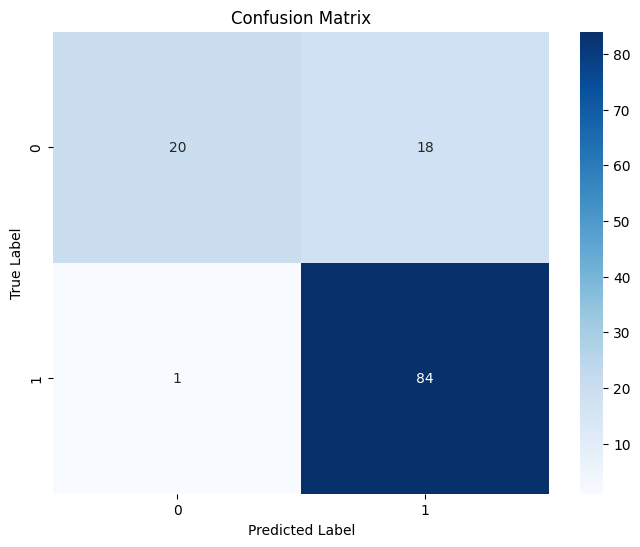

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The model is very good at finding mistakes (high recall: only one missed). It does set off some false alarms (18 safe borrowers were marked as risky), which makes it a little less accurate. This confusion matrix matches the  earlier test metrics (Accuracy 0.85, Precision 0.86, Recall 0.85, F1 0.83), which shows that the performance is balanced and reliable. In loan prediction, this is a good trade off it's better to flag a few safe borrowers than to miss actual defaulters.

# **FEATURES IMPORTNCE**
The **feature importance** in a Random Forest classifier is a measure of the degree to which each input variable is used in decision making by the model. Each decision tree in the forest splits the data based on the features. This reduces the uncertainty about the class. The model also measures the degree to which each feature improves the accuracy of the classifier. Features with high splits are assigned high importance, while those with low splits are assigned low importance. This is useful in determining the features, such as credit history, income, and loan amount, which are most significant in predicting default.

In [ ]:
# Feature importance for Random Forest
feature_importance_rf_class = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_classifier.feature_importances_
})

# Sort by importance
feature_importance_rf_class = feature_importance_rf_class.sort_values('Importance', ascending=False)

# Display
display(feature_importance_rf_class)

,Feature,Importance
8,Credit_History,0.434794
4,ApplicantIncome,0.149485
6,LoanAmount,0.131028
5,CoapplicantIncome,0.100341
9,Property_Area_Semiurban,0.063385
2,Education,0.026061
1,Married,0.023226
10,Property_Area_Urban,0.019539
12,Dependents_2.0,0.013761
11,Dependents_1.0,0.013100


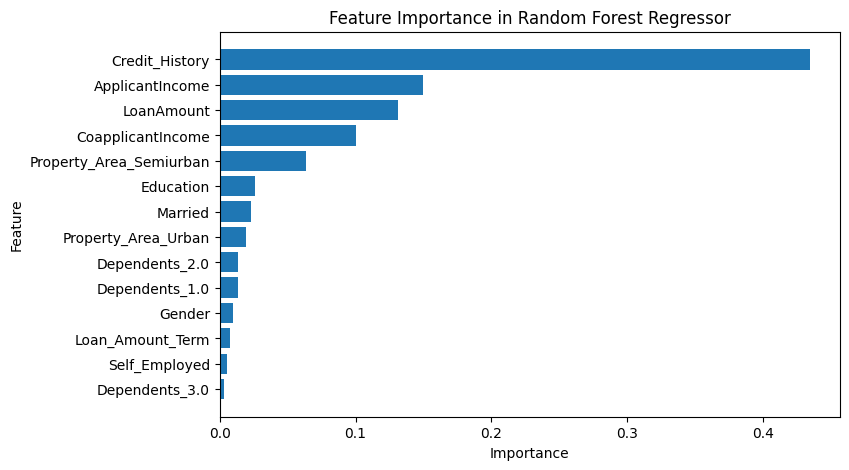

In [ ]:
sorted_importance_rf = feature_importance_rf_class.sort_values(by = 'Importance', ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(sorted_importance_rf['Feature'], sorted_importance_rf['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Regressor')
plt.show()

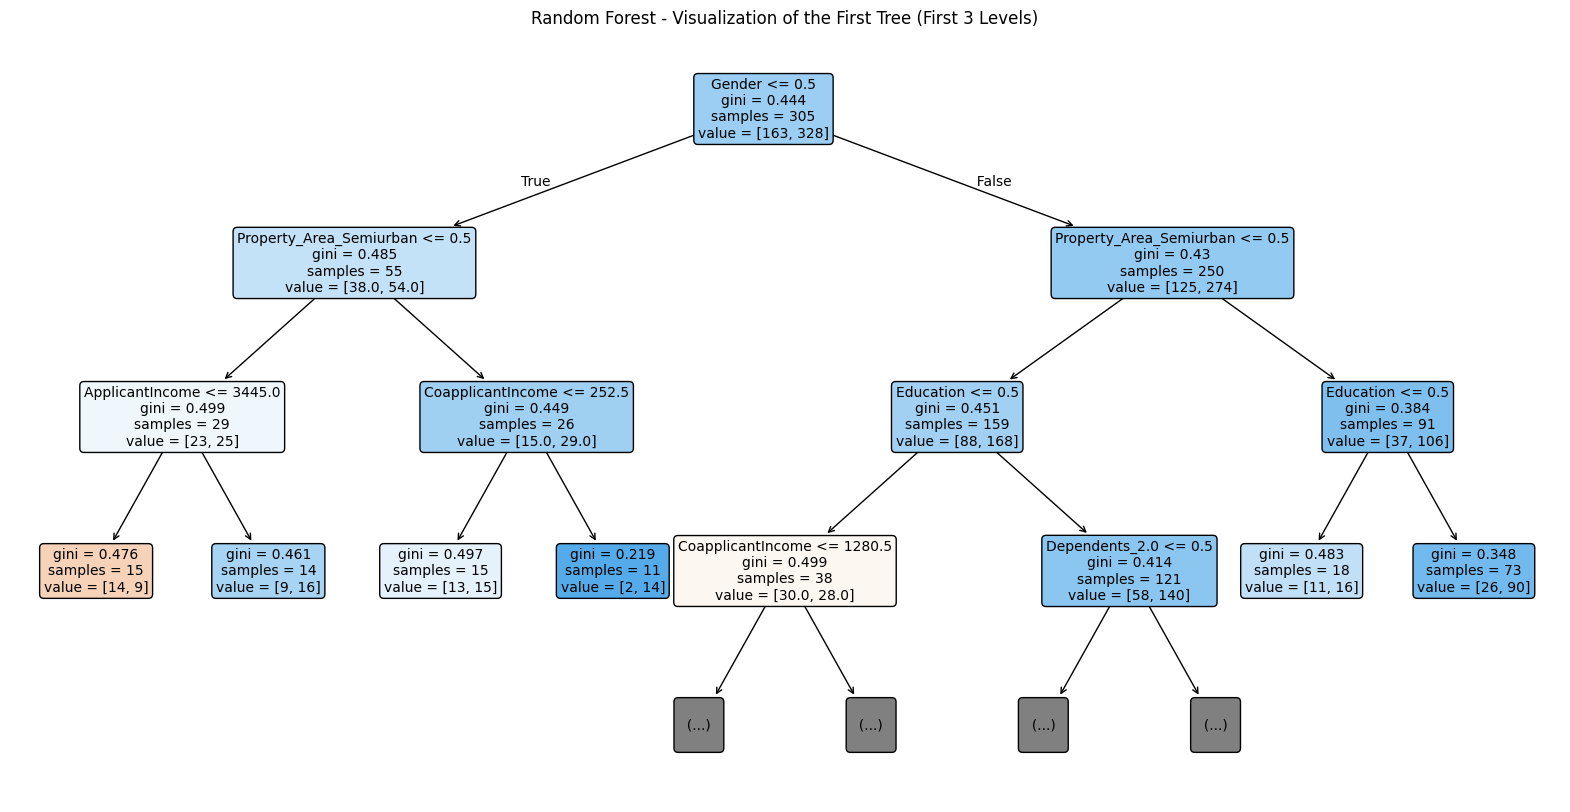

In [ ]:
plt.figure(figsize=(20, 10))
rf_features = X.columns

# Access the first estimator (tree) from the Random Forest
# You can change the index ([0], [1], etc.) to view different trees

tree.plot_tree(rf_classifier.estimators_[0],
               feature_names=rf_features,
               max_depth=3,
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Random Forest - Visualization of the First Tree (First 3 Levels)')
plt.show()

This decision tree visualization shows how one of the trees in the Random Forest classifier makes predictions about loan status. Each node is a decision point based on a feature, and each branch represents the outcome of that condition. The metrics inside nodes (like gini, samples, and value) explain how pure the split is, how many data points fall into that node, and the class distribution.

# **MODEL COMPARISON**

* The Random Forest Classifier model is the best algorithm in predicting loan approval because it provides better results in all parameters of evaluating a model. It provides a high accuracy of 84.6% compared to 82.9%, a high precision of 86.3% compared to 82.8%, and a high recall of 84.6% compared to 82.9%. Most importantly, it eliminates the chances of rejecting good loans because it identifies almost all good loans. It may have a slightly higher chance of rejecting good loans compared to the Logistic Regression algorithm. However, it is worth the trade off because it eliminates the chances of missing good loans, and therefore, more good loans are sanctioned, leading to business growth.

#  **RECOMMENDATION**
Random Forest is recommended as the production model because:
* The performance improvements justify the added complexity
* Feature importance provides sufficient interpretability for business needs
* The model handles the imbalanced dataset more effectively
* Better generalization reduces the risk of future prediction errors


#  **BUSSINESS  IMPACT**

# **Risk Reduction**
The model’s precise identification of riskier loan applications facilitates:

**Proactive Denial** : Rejection of riskier loan applications based on the probability of default

**Risk-Based Pricing** : Adjusting the rate of interest according to the riskiness of the loan application

**Enhanced Monitoring** : More monitoring of the riskier loans that are accepted

**Loss Prevention** : Reduction of the default rate of the entire portfolio of loans

# **Operational Efficiency**
The model enhances operational efficiency through:

 **Automated Screening**: Minimizing the need for manual screening of low-risk loan applications

 **Prioritized Review**: Focusing human expertise on borderline cases

 **Consistent Decisions**: Standardizing risk assessment for all loan applications

 **Faster Processing**: Improving the speed of loan approvals for eligible borrowers

# **Financial Benefits**

The implementation of the Random Forest model is likely to result in:

 **Reducing Default Losses**: Defaults are picked up earlier in the loan approval process

 **Optimizing Portfolio**: Optimizing risk-return trade-offs for the loan portfolio

 **Improving Margins**: Optimizing loan pricing to ensure correct interest rates

 **Deriving Competitive Advantage**: Data-driven decision making is superior to traditional decision making

# **Contact Information for Group 10 members**

| Name                  | Email                          | GitHub Repository |
|-----------------------|--------------------------------|------------------|
| **Sulaiman Fareed Oyindamola** | **sulaimanfareed86@gmail.com**    |**https://github.com/sulaimanfareed86-png/TS_Academy_Capstone_Project** |
| **Oladipo Zainab Oyindamola**  | **zainaboladipo@outlook.com**     |**https://github.com/Zainab-Oladipo/TS-Academy-Capstone-Project** |
| **Wisdom Alawode**                | **alawodewisdom02@gmail.com**  |**https://github.com/wisdomnotai/TS_Academy_Capstone_Project**  |
| **Wade Markus**            |**Markuswade62@gmail.com**             |**https://github.com/markuswade62-ops/TS_Academy_Capstone_Project** |
| **Amabetari Bodisere Biefa**    |**biefabodisere12@gmail.com**     |**https://github.com/Bodis-ama/Ts-_Academy_-Capstone_-Project** |
| **Joy Atume**             | **joy4atume@gmail.com**                |**https://github.com/Khara26/TS_Academy_Capstone_Project** |
| **Bashir**                | **bashirhassanmaidoki@gmail.com**      |**https://github.com/Bashd3rd/TS_Academy_Capstone_Project** |
| **Emeka Chinedu**         | **Obaoneconcept@yahoo.com**            |**https://github.com/Chinedu-007/Ts_Academy_Capstone_Project**|    